In [ ]:
#| default_exp auto_transformation

## Automatic Encoding for Categorical Variables

To encode calendar features as categorical variables, we can use any suitable encoding method from the `sklearn.preprocessing` module, such as `OneHotEncoder`, `TargetEncoder`, or `OrdinalEncoder`.

In three examples, we will use `OneHotEncoder` to encode the categorical variables in our dataset. This method creates new binary columns for each category in the original variable.

In [ ]:

from sklearn.preprocessing import OneHotEncoder
import numpy as np
import pandas as pd
from peshbeen.models import ml_forecaster
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

date_range = pd.date_range(start='2020-01-01', periods=720, freq='D')
# create a non-stationary arbitrary flower sales data with an upward trend, weekly seasonality, and yearly seasonality
np.random.seed(42)
data = 30 + 0.07 * np.arange(720) + 10 * np.sin(2 * np.pi * date_range.dayofyear / 7) + 10 * np.sin(2 * np.pi * date_range.dayofyear / 365) + np.random.normal(0, 5, 720)

sales_data = pd.DataFrame(data, index=date_range, columns=['sales'])
sales_data["week_day"] = sales_data.index.dayofweek
sales_data["month"] = sales_data.index.month
cat_vars = ["week_day", "month"]
train = sales_data.iloc[:-30]
test = sales_data.iloc[-30:]

# Example of using OneHotEncoder for XGBoost
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop="first")

xgb = ml_forecaster(target_col="sales", model=XGBRegressor(n_estimators=100, random_state=42),
                    lags = 6,
                    cat_variables=cat_vars, categorical_encoder=ohe)
xgb.fit(train)
xgb_forecasts = xgb.forecast(30, exog=test[cat_vars])

In [ ]:
# How the transformed features look like for XGBoost
xgb.X.head()

,week_day_1,week_day_2,week_day_3,week_day_4,week_day_5,week_day_6,month_2,month_3,month_4,month_5,...,month_9,month_10,month_11,month_12,sales_lag_1,sales_lag_2,sales_lag_3,sales_lag_4,sales_lag_5,sales_lag_6
2020-01-07,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,22.392017,20.219602,34.174336,38.233477,39.472174,40.474019
2020-01-08,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,39.518145,22.392017,20.219602,34.174336,38.233477,39.472174
2020-01-09,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,43.518276,39.518145,22.392017,20.219602,34.174336,38.233477
2020-01-10,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,39.504995,43.518276,39.518145,22.392017,20.219602,34.174336
2020-01-11,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,39.394569,39.504995,43.518276,39.518145,22.392017,20.219602


In [ ]:
## Example of using TargetEncoder for LightGBM
from sklearn.preprocessing import TargetEncoder
te = TargetEncoder(cv=5)
lgb = ml_forecaster(target_col="sales", model=LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
                    lags = 6,
                    cat_variables=cat_vars, categorical_encoder=te)
lgb.fit(train)
lgb_forecasts = lgb.forecast(30, exog=test[cat_vars])

In [ ]:
# How the transformed features look like for LightGBM
lgb.X.head()

,week_day,month,sales_lag_1,sales_lag_2,sales_lag_3,sales_lag_4,sales_lag_5,sales_lag_6
2020-01-07,50.118039,46.945004,22.392017,20.219602,34.174336,38.233477,39.472174,40.474019
2020-01-08,55.195593,47.235865,39.518145,22.392017,20.219602,34.174336,38.233477,39.472174
2020-01-09,59.591927,46.210753,43.518276,39.518145,22.392017,20.219602,34.174336,38.233477
2020-01-10,59.436795,46.478067,39.504995,43.518276,39.518145,22.392017,20.219602,34.174336
2020-01-11,57.761881,49.035528,39.394569,39.504995,43.518276,39.518145,22.392017,20.219602


## Automatic Transformations for Rolling Window Features

peshbeen supports user-specified rolling window features — such as rolling means and standard deviations — which can be particularly useful for ML regressors as they capture recent dynamics in the series. Beyond feature engineering, peshbeen can automatically apply a Box-Cox transformation to the target variable when the data exhibits heteroscedasticity, stabilising variance before model fitting and improving forecast reliability.

In [ ]:
#| hide
import matplotlib.pyplot as plt
plt.rcParams['figure.facecolor'] = "#FBFAF4"
plt.rcParams['axes.facecolor'] = "#FBFAF4"

# dont show warnings
import warnings
warnings.filterwarnings("ignore")

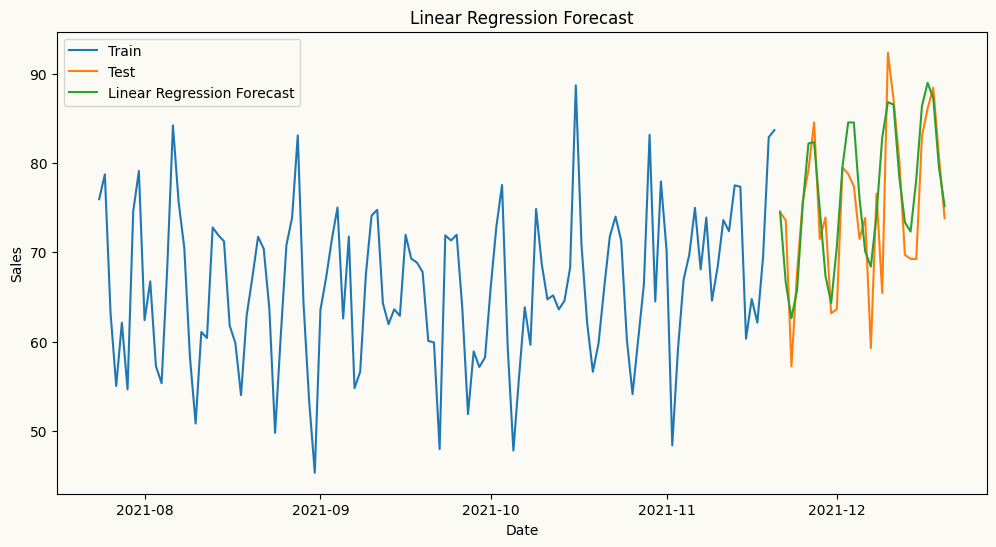

In [ ]:
import matplotlib.pyplot as plt
from peshbeen.transformations import rolling_mean, rolling_quantile, rolling_std, expanding_mean
from peshbeen.models import ml_forecaster
from sklearn.linear_model import LinearRegression

transformations = [rolling_std(window_size=30, shift=1), rolling_mean(window_size=30, shift=7),
                   rolling_quantile(window_size=30, shift=1, quantile=0.25),
                   rolling_quantile(window_size=30, shift=1, quantile=0.75), expanding_mean(shift=1)]
linear_model = ml_forecaster(model=LinearRegression(),
              target_col='sales', lags = 7, box_cox=0.5,
              lag_transform=transformations, cat_variables=cat_vars, categorical_encoder=ohe)
linear_model.fit(train)
# linear_model.data_prep(train)
forecasts = linear_model.forecast(H=30, exog=test[cat_vars])

# plot the forecast and the actual values
plt.figure(figsize=(12, 6))
plt.plot(train.index[-120:], train['sales'][-120:], label='Train')
plt.plot(test.index, test['sales'], label='Test')
plt.plot(test.index, forecasts, label='Linear Regression Forecast')
plt.title('Linear Regression Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [ ]:
# How the transformed features look like for Linear Regression
linear_model.X.head()

,week_day_1,week_day_2,week_day_3,week_day_4,week_day_5,week_day_6,month_2,month_3,month_4,month_5,...,sales_lag_3,sales_lag_4,sales_lag_5,sales_lag_6,sales_lag_7,rolling_std_30_shift_1,rolling_mean_30_shift_7,rolling_quantile_30_shift_1_q0.25,rolling_quantile_30_shift_1_q0.75,expanding_mean_shift_1
2020-01-08,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.993242,9.691764,10.366645,10.565377,10.723839,1.581041,10.723839,8.577902,10.569034,9.482514
2020-01-09,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.464041,6.993242,9.691764,10.366645,10.565377,1.583857,10.644608,9.134833,10.610479,9.696410
2020-01-10,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.572692,7.464041,6.993242,9.691764,10.366645,1.509947,10.551954,9.691764,10.572692,9.793542
2020-01-11,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,11.193677,10.572692,7.464041,6.993242,9.691764,1.443708,10.336906,9.860484,10.572169,9.869489
2020-01-12,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,10.570600,11.193677,10.572692,7.464041,6.993242,1.460908,9.668173,8.937674,10.571646,9.716225


**Fourier Terms for Seasonal Patterns**

For series with strong seasonal patterns, peshbeen can automatically generate Fourier terms as a DataFrame indexed to match the original series — making them ready to merge as exogenous variables in a single line. Calendar features such as month or day of week can be added directly to the same DataFrame, and peshbeen will automatically encode them as categorical variables. This covers a wide range of calendar effects, from weekend sales spikes to holiday demand shifts.

In [ ]:
from peshbeen.transformations import fourier_terms
# create fourier terms for yearly seasonality with period 365 and number of terms 2 to be used as exogenous variables in the model
sales_exog = sales_data.copy() # create a copy of the original data to store the fourier terms

sales_exog.drop(columns=["month"], inplace=True) # drop month column because we will use fourier terms to capture the yearly seasonality instead of using month as a categorical variable
fourier_trms = fourier_terms(index=sales_exog.index, period=365, num_terms=2)
sales_exog = sales_exog.merge(fourier_trms, left_index=True, right_index=True) # merge the fourier terms with the original data to be used as exogenous variables in the model
sales_exog.head()

,sales,week_day,sin_1_365,sin_2_365,cos_1_365,cos_2_365
2020-01-01,40.474019,2,0.000000,0.000000,1.000000,1.000000
2020-01-02,39.472174,3,0.017213,0.034422,0.999852,0.999407
2020-01-03,38.233477,4,0.034422,0.068802,0.999407,0.997630
2020-01-04,34.174336,5,0.051620,0.103102,0.998667,0.994671
2020-01-05,20.219602,6,0.068802,0.137279,0.997630,0.990532


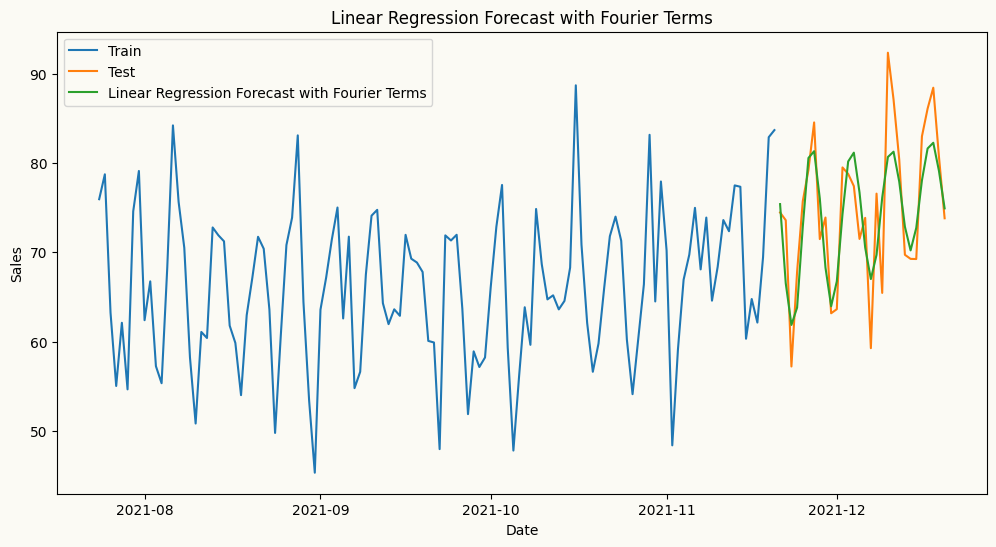

In [ ]:
# split the data into train and test
from sklearn.linear_model import Lasso
train_exog = sales_exog.iloc[:-30]
test_exog = sales_exog.iloc[-30:].drop(columns=['sales']) # drop the target column from the exogenous variables for the test set
# ml forecast using Linear Regression with fourier terms as exogenous variables
lr_model = ml_forecaster(model=Lasso(alpha=0.1),
              target_col='sales', lags = 7, lag_transform=transformations,
              cat_variables=["week_day"], categorical_encoder=ohe)
lr_model.fit(train_exog)
lr_forecast = lr_model.forecast(H=30, exog=test_exog)
# plot the forecast and the actual values
plt.figure(figsize=(12, 6))
plt.plot(train.index[-120:], train['sales'][-120:], label='Train')
plt.plot(test.index, test['sales'], label='Test')
plt.plot(test.index, lr_forecast, label='Linear Regression Forecast with Fourier Terms')
plt.title('Linear Regression Forecast with Fourier Terms')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()